In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/modeling_table_pm25_met.csv", parse_dates=["date"])
df.head()


,State Name,County Name,Site Num,Latitude,Longitude,Arithmetic Mean,Units of Measure,Sample Duration,Observation Count,source_file,date,met_station,temp,dewpoint,sea_level_pressure,wind_speed,precipitation,snow_depth
0,District Of Columbia,District of Columbia,41,38.895572,-76.958072,7.625000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-01,DCA,1.15,-7.454167,-16.512500,1031.658333,7730,46.291667
1,District Of Columbia,District of Columbia,41,38.895572,-76.958072,9.625000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-02,DCA,1.15,-7.683333,-18.929167,1034.458333,-3279,46.375000
2,District Of Columbia,District of Columbia,41,38.895572,-76.958072,17.041667,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-03,DCA,1.15,-4.975000,-13.862500,1026.762500,-17248,14.500000
3,District Of Columbia,District of Columbia,41,38.895572,-76.958072,8.250000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-04,DCA,1.15,-3.120833,-9.516667,758.362500,5960,77.500000
4,District Of Columbia,District of Columbia,41,38.895572,-76.958072,2.416667,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-05,DCA,1.15,-8.454167,-19.987500,1017.025000,7130,78.041667


In [7]:
#MINIMAL CLEANING
# Target
y_col = "Arithmetic Mean"

# Keep only rows with met features present
feature_cols = ["temp", "dewpoint", "wind_speed", "sea_level_pressure", "precipitation"]
available = [c for c in feature_cols if c in df.columns]

df = df.dropna(subset=[y_col] + available).copy()

# Basic time features
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek

available += ["month", "dow"]

print("Rows after dropna:", len(df))
print("Date range:", df["date"].min(), df["date"].max())


Rows after dropna: 33723
Date range: 2018-01-01 00:00:00 2024-12-31 00:00:00


In [5]:
#TRAIN/TEST SPLIT BY TIME
train = df[df["date"].dt.year.isin([2018, 2019, 2022, 2023])]
test  = df[df["date"].dt.year == 2024]

X_train = train[available]
y_train = train[y_col]
X_test  = test[available]
y_test  = test[y_col]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (22104, 7) Test: (11619, 7)


In [13]:
#RIDGE BASELINE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
print("Ridge MAE:", mae)
print("Ridge RMSE:", rmse)

Ridge MAE: 3.1310068455203837
Ridge RMSE: 4.1077873667911415


In [19]:
#TREE BASELINE (RANDOM FOREST)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5
print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 2.878761655065117
RF RMSE: 3.738095771936801


In [25]:
results = pd.DataFrame({
    "model": ["Ridge", "RandomForest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
})
results


,model,MAE,RMSE
0,Ridge,3.131007,4.107787
1,RandomForest,2.878762,3.738096


In [27]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
)

perm_imp = pd.Series(
    perm.importances_mean,
    index=available
).sort_values(ascending=False)

perm_imp


dewpoint              0.251569
precipitation         0.169166
sea_level_pressure    0.132126
wind_speed            0.037436
month                 0.003252
temp                  0.000034
dow                  -0.021923
dtype: float64

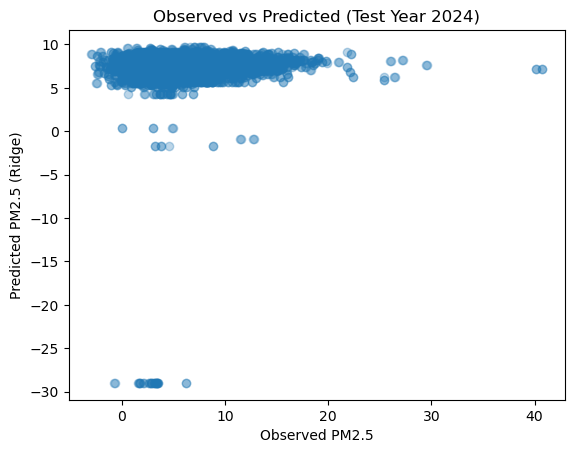

In [21]:
#EVALUTAION PLOT
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, pred, alpha=0.3)
plt.xlabel("Observed PM2.5")
plt.ylabel("Predicted PM2.5 (Ridge)")
plt.title("Observed vs Predicted (Test Year 2024)")
plt.savefig("../figures/obs_vs_pred_ridge.png", dpi=200, bbox_inches="tight")
plt.show()


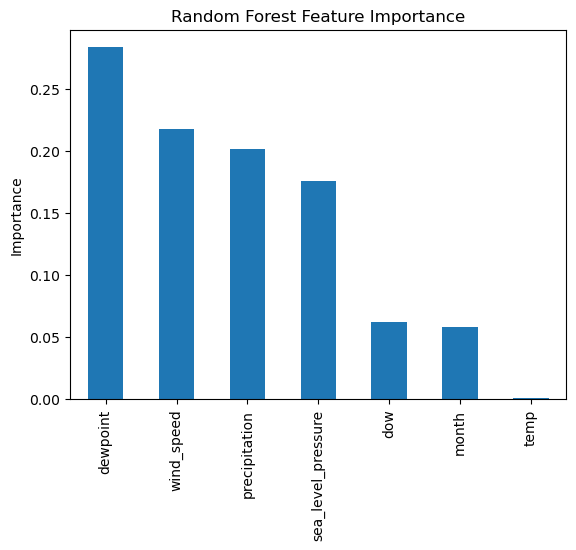

dewpoint              0.283607
wind_speed            0.217817
precipitation         0.201202
sea_level_pressure    0.175759
dow                   0.062510
month                 0.058522
temp                  0.000583
dtype: float64

In [23]:
imp = pd.Series(rf.feature_importances_, index=available).sort_values(ascending=False)

plt.figure()
imp.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.savefig("../figures/rf_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

imp
